In [117]:
# Cài đặt thư viện
import torch

# Tự động lấy phiên bản Torch và CUDA phù hợp
TORCH_version = torch.__version__.split("+")[0]
CUDA_version = (
    "cpu"
    if not torch.cuda.is_available()
    else f"cu{torch.version.cuda.replace('.', '')}"
)

print(f"Torch version: {TORCH_version}")
print(f"CUDA version: {CUDA_version}")

# Cài đặt các thư viện bổ trợ
!pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_version}+{CUDA_version}.html
!pip install -q torch-geometric

Torch version: 2.11.0
CUDA version: cu128


In [118]:
import os, gc, gzip, urllib.request
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.utils import degree

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device: cuda
PyTorch: 2.11.0+cu128


In [119]:
# Tải dữ liệu từ snap
EDGE_URL  = 'https://snap.stanford.edu/data/soc-pokec-relationships.txt.gz'
PROF_URL  = 'https://snap.stanford.edu/data/soc-pokec-profiles.txt.gz'
EDGE_FILE = 'pokec_edges.txt.gz'
PROF_FILE = 'pokec_profiles.txt.gz'

def download_if_needed(url, fname):
    if not os.path.exists(fname):
        print(f'Đang tải {fname} ...')
        urllib.request.urlretrieve(url, fname)
        print(f'Tải xong: {fname}')
    else:
        print(f'Đã có: {fname}')

download_if_needed(EDGE_URL, EDGE_FILE)
download_if_needed(PROF_URL, PROF_FILE)

Đã có: pokec_edges.txt.gz
Đã có: pokec_profiles.txt.gz


In [120]:
# Đọc cạnh và xây dựng đồ thị
print('Đọc danh sách cạnh ...')
src_list, dst_list = [], []

with gzip.open(EDGE_FILE, 'rt') as f:
    for line in f:
        u, v = line.strip().split()
        src_list.append(int(u))
        dst_list.append(int(v))

src_arr = np.array(src_list, dtype=np.int32)
dst_arr = np.array(dst_list, dtype=np.int32)
del src_list, dst_list
gc.collect()

# Re-index từ 0
all_nodes = np.unique(np.concatenate([src_arr, dst_arr]))
node2idx  = {n: i for i, n in enumerate(all_nodes)}
N = len(all_nodes)
src_idx = np.array([node2idx[u] for u in src_arr], dtype=np.int32)
dst_idx = np.array([node2idx[v] for v in dst_arr], dtype=np.int32)
del src_arr, dst_arr
gc.collect()

E = len(src_idx)
density = E / (N * (N - 1))

print(f'\nTHỐNG KÊ ĐỒ THỊ')
print(f'  Số đỉnh (N)  : {N:,}')
print(f'  Số cạnh (E)  : {E:,}')
print(f'  Mật độ       : {density:.2e}')

Đọc danh sách cạnh ...

THỐNG KÊ ĐỒ THỊ
  Số đỉnh (N)  : 1,632,803
  Số cạnh (E)  : 30,622,564
  Mật độ       : 1.15e-05


In [121]:
# Tính bậc vào và bậc ra mỗi đỉnh
out_deg = np.bincount(src_idx, minlength=N).astype(np.float32)
in_deg  = np.bincount(dst_idx, minlength=N).astype(np.float32)
print(f'In-degree  — max: {in_deg.max():.0f}, mean: {in_deg.mean():.2f}')
print(f'Out-degree — max: {out_deg.max():.0f}, mean: {out_deg.mean():.2f}')

In-degree  — max: 13733, mean: 18.75
Out-degree — max: 8763, mean: 18.75


In [122]:
# Approximate Personalized PageRank (APPr) — Gán nhãn
# --- Xây dựng ma trận chuyển tiếp thưa
data_vals = np.ones(E, dtype=np.float32)
# Chuẩn hóa theo bậc ra (D^{-1} A)
out_deg_safe = np.where(out_deg == 0, 1, out_deg)
norm_vals = data_vals / out_deg_safe[src_idx]

P = sp.csr_matrix(
    (norm_vals, (src_idx, dst_idx)),
    shape=(N, N),
    dtype=np.float32
)
del norm_vals, data_vals
gc.collect()
print('Ma trận chuyển tiếp P đã xây dựng (sparse CSR)')

# --- APPr Power Iteration (alpha = 0.15, K = 5 bước) ---
# Score xấp xỉ: r = alpha * e + (1-alpha) * P^T r   (column-stochastic view)
# Ở đây dùng in-degree làm seed (mỗi đỉnh nhận seed tỉ lệ in-degree)
alpha = 0.15
K = 5

# Dùng in_deg làm vector khởi tạo (float64 để ổn định)
r = in_deg.astype(np.float64)
r_norm = r / (r.sum() + 1e-12)

print(f'Chạy APPr với alpha={alpha}, K={K} bước ...')
for k in range(K):
    r_norm = alpha * (in_deg / (in_deg.sum() + 1e-12)) + (1 - alpha) * P.T.dot(r_norm)
    if k % 1 == 0:
        print(f'  Bước {k+1}/{K} — min={r_norm.min():.4e}, max={r_norm.max():.4e}')

appr_score = r_norm.astype(np.float32)
del r, r_norm, P
gc.collect()
print('APPr hoàn tất')

Ma trận chuyển tiếp P đã xây dựng (sparse CSR)
Chạy APPr với alpha=0.15, K=5 bước ...
  Bước 1/5 — min=0.0000e+00, max=4.8349e-04
  Bước 2/5 — min=0.0000e+00, max=4.4863e-04
  Bước 3/5 — min=0.0000e+00, max=4.3879e-04
  Bước 4/5 — min=0.0000e+00, max=4.2583e-04
  Bước 5/5 — min=0.0000e+00, max=4.1879e-04
APPr hoàn tất


In [123]:
# --- Gán nhãn dựa trên phân vị APPr score ---
# 0: clone/spam   (< p10)
# 1: casual       (p10 – p75)
# 2: potential    (p75 – p95)
# 3: influencer   (>= p95)

p10 = np.percentile(appr_score, 10)
p75 = np.percentile(appr_score, 75)
p95 = np.percentile(appr_score, 95)

labels = np.zeros(N, dtype=np.int64)
labels[appr_score >= p10] = 1
labels[appr_score >= p75] = 2
labels[appr_score >= p95] = 3

label_names = {0: 'Clone/Spam', 1: 'Casual', 2: 'Potential', 3: 'Influencer'}
cnt = Counter(labels.tolist())
print('\n📌 Phân bố nhãn APPr:')
for k, name in label_names.items():
    print(f'  {k} — {name:15s}: {cnt[k]:>8,} đỉnh  ({cnt[k]/N*100:.1f}%)')


📌 Phân bố nhãn APPr:
  0 — Clone/Spam     :  163,281 đỉnh  (10.0%)
  1 — Casual         : 1,061,321 đỉnh  (65.0%)
  2 — Potential      :  326,560 đỉnh  (20.0%)
  3 — Influencer     :   81,641 đỉnh  (5.0%)


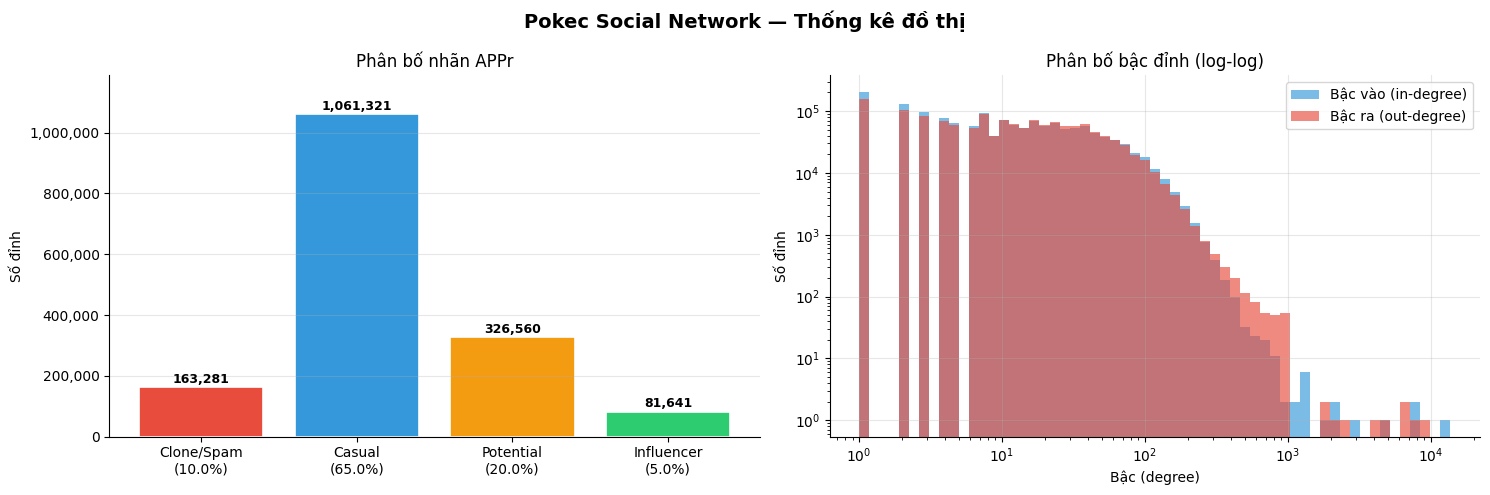

In [124]:
# Biểu đồ 1: phân bố nhãn
# Biểu đồ 2: phân bố bậc
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pokec Social Network — Thống kê đồ thị', fontsize=14, fontweight='bold')

# --- Biểu đồ 1: Số lượng từng nhãn ---
ax1 = axes[0]
colors = ['#e74c3c', '#3498db', '#f39c12', '#2ecc71']
bar_labels = [f"{label_names[k]}\n({cnt[k]/N*100:.1f}%)" for k in range(4)]
bars = ax1.bar(bar_labels, [cnt[k] for k in range(4)], color=colors, edgecolor='white', linewidth=1.2)
for bar, k in zip(bars, range(4)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + N*0.003,
             f'{cnt[k]:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_title('Phân bố nhãn APPr', fontsize=12)
ax1.set_ylabel('Số đỉnh')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.set_ylim(0, max(cnt.values()) * 1.12)
ax1.grid(axis='y', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# --- Biểu đồ 2: Phân bố bậc vào / bậc ra (log-scale histogram) ---
ax2 = axes[1]
bins = np.logspace(0, np.log10(max(in_deg.max(), out_deg.max()) + 1), 60)
ax2.hist(in_deg[in_deg > 0],  bins=bins, alpha=0.65, color='#3498db', label='Bậc vào (in-degree)')
ax2.hist(out_deg[out_deg > 0], bins=bins, alpha=0.65, color='#e74c3c', label='Bậc ra (out-degree)')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Phân bố bậc đỉnh (log-log)', fontsize=12)
ax2.set_xlabel('Bậc (degree)')
ax2.set_ylabel('Số đỉnh')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


In [125]:
#   x1 = in_degree          (số người follow)
#   x2 = log(in_degree+1)   (log của bậc vào, giúp ổn định giá trị)
#   x3 = in_deg / (in_deg + out_deg + 1.0)      (tỷ lệ in-degree trên tổng degree, nhấn mạnh sự thống trị của in-degree)
#   x4 = appr_score         (điểm APPr)
#   x5 = in_deg - out_deg   (chênh lệch tuyệt đối, thưởng cho in-degree cao và phạt out-degree cao)

print('Tạo ma trận đặc trưng (tập trung vào in-degree)...')
x1 = in_deg
x2 = np.log1p(in_deg)
x3 = in_deg / (in_deg + out_deg + 1.0) # Giữ lại tỷ lệ
x4 = appr_score
x5 = in_deg - out_deg # Đặc trưng mới quan trọng

# Loại bỏ out_degree khỏi các đặc trưng chính
X_raw = np.column_stack([x1, x2, x3, x4, x5]).astype(np.float32)
print(f'Shape X_raw: {X_raw.shape}')

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

# Naive Bayes — dùng ~20% node làm pseudo-train (có nhãn từ APPr)
rng = np.random.default_rng(42)
train_mask = rng.random(N) < 0.20
print(f'Số node train (Bayes): {train_mask.sum():,}')

nb = GaussianNB()
nb.fit(X_scaled[train_mask], labels[train_mask])

# Xác suất có điều kiện từ Bayes — shape (N, 4)
print('Tính xác suất Bayes cho toàn bộ đỉnh ...')
# Xử lý theo batch để tiết kiệm RAM
BATCH = 200_000
proba_parts = []
for i in range(0, N, BATCH):
    proba_parts.append(nb.predict_proba(X_scaled[i:i+BATCH]).astype(np.float32))
bayes_proba = np.vstack(proba_parts)  # shape (N, 4)
del proba_parts
gc.collect()

print(f'Bayes proba shape: {bayes_proba.shape}')
nb_pred = np.argmax(bayes_proba, axis=1)
nb_acc = accuracy_score(labels[train_mask], nb_pred[train_mask])
print(f'Naive Bayes train accuracy: {nb_acc:.4f}')

Tạo ma trận đặc trưng (tập trung vào in-degree)...
Shape X_raw: (1632803, 5)
Số node train (Bayes): 326,554
Tính xác suất Bayes cho toàn bộ đỉnh ...
Bayes proba shape: (1632803, 4)
Naive Bayes train accuracy: 0.9439


In [126]:
# Ghép đặc trưng: raw features + Bayes probabilities
#  Feature cuối = [X_scaled | bayes_proba]  shape (N, 9)
X_feat = np.hstack([X_scaled, bayes_proba]).astype(np.float32)
print(f'Feature matrix shape: {X_feat.shape}  (5 raw + 4 Bayes proba)')
del X_scaled, X_raw
gc.collect()

Feature matrix shape: (1632803, 9)  (5 raw + 4 Bayes proba)


0

In [127]:
#Xây dựng PyG Data object — SPARSE edge_index

# SubSample edges: chỉ giữ các cạnh kết nối với node có label >= 1 (bỏ clone đơn thuần)
# và giới hạn tối đa 3M cạnh cho VRAM an toàn
MAX_EDGES = 3_000_000

keep_mask = (labels[src_idx] >= 1) | (labels[dst_idx] >= 1)
s_keep = src_idx[keep_mask]
d_keep = dst_idx[keep_mask]
print(f'Cạnh sau lọc: {len(s_keep):,}')

if len(s_keep) > MAX_EDGES:
    chosen = rng.choice(len(s_keep), MAX_EDGES, replace=False)
    s_keep = s_keep[chosen]
    d_keep = d_keep[chosen]
    print(f'⚠️ Đã sample xuống {MAX_EDGES:,} cạnh để tiết kiệm VRAM')

edge_index = torch.tensor(np.vstack([s_keep, d_keep]), dtype=torch.long)  # (2, E')
node_feats  = torch.tensor(X_feat, dtype=torch.float32)
node_labels = torch.tensor(labels, dtype=torch.long)

# Train / Val / Test mask
train_idx = np.where(train_mask)[0]
rest_idx  = np.where(~train_mask)[0]
val_idx   = rng.choice(rest_idx, size=int(0.1 * N), replace=False)
test_mask_arr = np.ones(N, dtype=bool)
test_mask_arr[train_idx] = False
test_mask_arr[val_idx]   = False

train_mask_t = torch.zeros(N, dtype=torch.bool)
val_mask_t   = torch.zeros(N, dtype=torch.bool)
test_mask_t  = torch.zeros(N, dtype=torch.bool)
train_mask_t[train_idx] = True
val_mask_t[val_idx]     = True
test_mask_t[test_mask_arr] = True

data = Data(
    x=node_feats,
    edge_index=edge_index,
    y=node_labels,
    train_mask=train_mask_t,
    val_mask=val_mask_t,
    test_mask=test_mask_t
)
print(data)
del s_keep, d_keep, X_feat
gc.collect()

Cạnh sau lọc: 30,608,500
⚠️ Đã sample xuống 3,000,000 cạnh để tiết kiệm VRAM
Data(x=[1632803, 9], edge_index=[2, 3000000], y=[1632803], train_mask=[1632803], val_mask=[1632803], test_mask=[1632803])


0

## PHẦN 3 — Huấn luyện GAT

In [128]:
# Model 1
class GATInfluencer(nn.Module):
    """2-layer GAT tối ưu bộ nhớ cho Colab free."""
    def __init__(self, in_feats, hidden=32, out_classes=4, heads=4, dropout=0.4):
        super().__init__()
        self.gat1 = GATConv(in_feats, hidden, heads=heads, dropout=dropout, concat=True)
        self.gat2 = GATConv(hidden * heads, out_classes, heads=1, dropout=dropout, concat=False)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.elu(self.gat1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat2(x, edge_index)
        return x   # raw logits

IN_FEATS  = data.num_node_features  # 9
model     = GATInfluencer(in_feats=IN_FEATS, hidden=32, out_classes=4, heads=4, dropout=0.4).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss()

# Class weights để xử lý imbalance
class_counts = np.array([cnt[k] for k in range(4)], dtype=np.float32)
class_weights = torch.tensor(1.0 / (class_counts / class_counts.sum()), dtype=torch.float32).to(DEVICE)
class_weights /= class_weights.sum()
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTổng tham số: {total_params:,}')

GATInfluencer(
  (gat1): GATConv(9, 32, heads=4)
  (gat2): GATConv(128, 4, heads=1)
)

Tổng tham số: 2,060


In [129]:
# Model 2
class ImprovedGAT(nn.Module):
    def __init__(self, in_feats, hidden=64, out_classes=4, heads=8, dropout=0.3):
        super().__init__()
        self.conv1 = GATConv(in_feats, hidden, heads=heads, dropout=dropout, concat=True)
        self.conv2 = GATConv(hidden*heads, hidden, heads=heads, dropout=dropout, concat=True)
        self.conv3 = GATConv(hidden*heads, out_classes, heads=1, dropout=dropout, concat=False)

        self.bn1 = nn.BatchNorm1d(hidden*heads)
        self.bn2 = nn.BatchNorm1d(hidden*heads)
        self.residual = nn.Linear(in_feats, out_classes)  # residual connection

    def forward(self, x, edge_index):
        residual = self.residual(x)

        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.bn1(self.conv1(x, edge_index)))

        x = F.dropout(x, p=0.2, training=self.training)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))

        x = self.conv3(x, edge_index)
        return x + residual   # Residual connection

# Khởi tạo lại model
model = ImprovedGAT(
    in_feats=data.num_node_features,
    hidden=16,
    heads=3,
    dropout=0.25
).to(DEVICE)

print("Improved GAT created!")

Improved GAT created!


In [130]:
# Di chuyển dữ liệu lên GPU
data = data.to(DEVICE)
print(f'Data trên: {data.x.device}')

if DEVICE.type == 'cuda':
    allocated = torch.cuda.memory_allocated(DEVICE) / 1e9
    print(f'VRAM đã dùng: {allocated:.2f} GB')

Data trên: cuda:0
VRAM đã dùng: 0.32 GB


In [131]:
# ====================== TẠO MASKS (nếu chưa có) ======================
if not hasattr(data, 'train_mask') or data.train_mask is None:
    print("Tạo train/val/test mask...")
    indices = torch.randperm(data.num_nodes)
    train_size = int(0.7 * data.num_nodes)
    val_size   = int(0.15 * data.num_nodes)

    train_idx = indices[:train_size]
    val_idx   = indices[train_size:train_size+val_size]
    test_idx  = indices[train_size+val_size:]

    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)

    data.train_mask[train_idx] = True
    data.val_mask[val_idx]     = True
    data.test_mask[test_idx]   = True

# ====================== TRAINING SETUP ======================
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau

DEVICE = next(model.parameters()).device

class_weights = torch.tensor([0.8, 1.0, 2.5, 6.0]).to(DEVICE)   # Tăng mạnh cho Influencer
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)
# Early Stopping
early_stopping_patience = 80
best_val_f1 = 0.0
best_model_state = None
counter = 0

# History
history = {
    'epoch': [], 'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []
}

EPOCHS = 300

# ====================== HÀM EVALUATE ======================
def evaluate(mask):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        loss = criterion_weighted(logits[mask], data.y[mask]).item()

        preds = logits[mask].argmax(dim=1).cpu().numpy()
        truths = data.y[mask].cpu().numpy()

        acc = accuracy_score(truths, preds)
        f1  = f1_score(truths, preds, average='macro', zero_division=0)
    return loss, acc, f1

from torch.cuda.amp import autocast, GradScaler

scaler = GradScaler()

# ====================== TRAINING LOOP ĐÃ TỐI ƯU MEMORY ======================
# Loss + Optimizer
class_weights = torch.tensor([0.7, 0.9, 2.8, 7.5]).to(DEVICE)  # Tăng mạnh Influencer
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.003, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=20)

# AMP
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

best_val_f1 = 0.0
best_model_state = None
best_epoch = 0
counter = 0
EPOCHS = 400

for epoch in range(1, 201):
    # Train với AMP
    model.train()
    optimizer.zero_grad()

    with autocast():
        logits = model(data.x, data.edge_index)
        loss = criterion_weighted(logits[data.train_mask], data.y[data.train_mask])

    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    scaler.step(optimizer)
    scaler.update()

    # --- Evaluate ---
    t_loss, t_acc, t_f1 = evaluate(data.train_mask)
    v_loss, v_acc, v_f1 = evaluate(data.val_mask)

    # Scheduler
    scheduler.step(v_f1)

    # Save history
    history['epoch'].append(epoch)
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    history['train_f1'].append(t_f1)
    history['val_f1'].append(v_f1)

    # Early Stopping & Best Model
    if v_f1 > best_val_f1:
        best_val_f1 = v_f1
        best_val_acc = v_acc
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())
        counter = 0
    else:
        counter += 1

    # Print log
    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]['lr']
        marker = ' ◄ BEST' if epoch == best_epoch else ''
        print(f"Epoch {epoch:3d} | "
              f"Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | "
              f"Val Acc: {v_acc:.4f} | Val F1: {v_f1:.4f} | LR: {current_lr:.6f}")

    # Early stopping
    if counter >= early_stopping_patience:
        print(f"\nEarly stopping tại epoch {epoch}!")
        break

# Load best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print(f"\n=== HOÀN TẤT ===")
print(f"Best Epoch  : {best_epoch}")
print(f"Best Validation Macro F1: {best_val_f1:.4f}")
print(f"Best Val Acc: {best_val_acc:.4f}")

/tmp/ipykernel_560/304901654.py:61: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_560/304901654.py:73: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch   1 | Train Loss: 1.2798 | Val Loss: 1.2853 | Val Acc: 0.1825 | Val F1: 0.1896 | LR: 0.003000


/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please us

Epoch  10 | Train Loss: 0.9971 | Val Loss: 1.0001 | Val Acc: 0.6045 | Val F1: 0.5398 | LR: 0.003000


/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please us

...

Epoch 180 | Train Loss: 0.2532 | Val Loss: 0.2549 | Val Acc: 0.9488 | Val F1: 0.9359 | LR: 0.003000


/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please us

Epoch 190 | Train Loss: 0.2437 | Val Loss: 0.2453 | Val Acc: 0.9484 | Val F1: 0.9360 | LR: 0.003000


/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_560/304901654.py:86: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please us

Epoch 200 | Train Loss: 0.2385 | Val Loss: 0.2400 | Val Acc: 0.9496 | Val F1: 0.9374 | LR: 0.003000

=== HOÀN TẤT ===
Best Epoch  : 200
Best Validation Macro F1: 0.9374
Best Val Acc: 0.9496


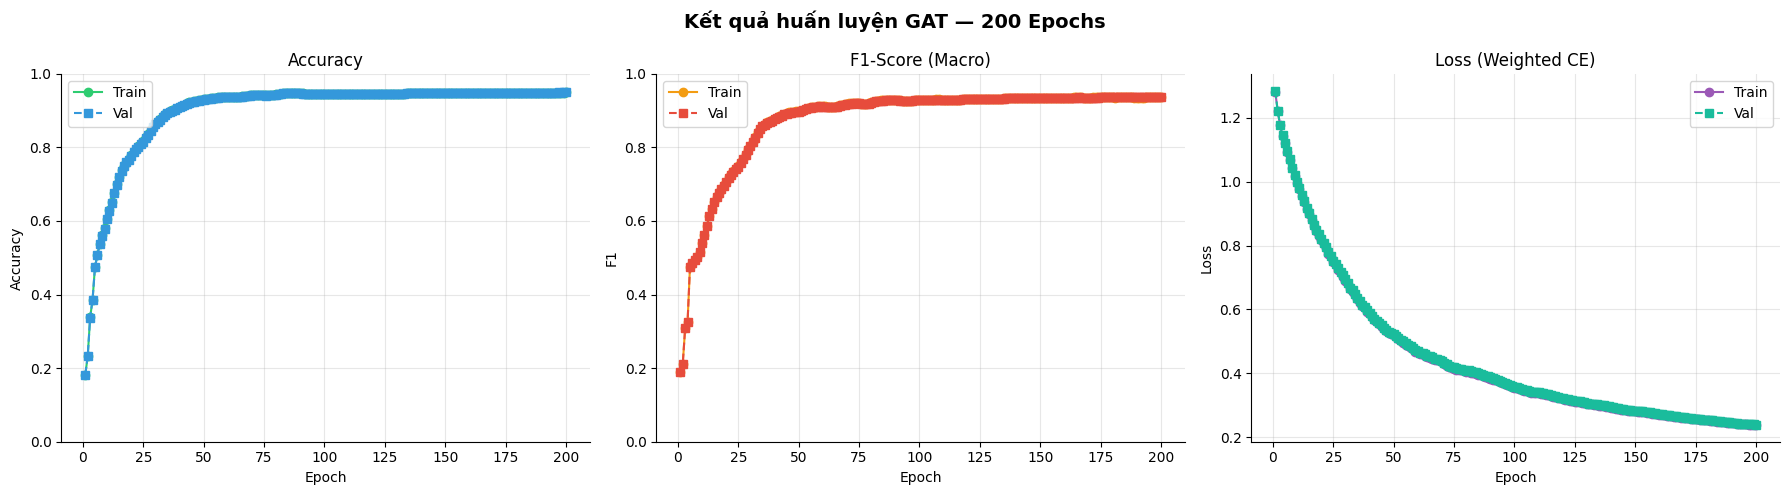

In [132]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Kết quả huấn luyện GAT — 200 Epochs', fontsize=14, fontweight='bold')
epochs_x = history['epoch']

# --- Accuracy ---
ax = axes[0]
ax.plot(epochs_x, history['train_acc'], 'o-', color='#2ecc71', label='Train')
ax.plot(epochs_x, history['val_acc'],   's--', color='#3498db', label='Val')
ax.set_title('Accuracy', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)

# --- F1-Score ---
ax = axes[1]
ax.plot(epochs_x, history['train_f1'], 'o-', color='#f39c12', label='Train')
ax.plot(epochs_x, history['val_f1'],   's--', color='#e74c3c', label='Val')
ax.set_title('F1-Score (Macro)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('F1')
ax.legend(); ax.grid(alpha=0.3)
ax.set_ylim(0, 1)
ax.spines[['top','right']].set_visible(False)

# --- Loss ---
ax = axes[2]
ax.plot(epochs_x, history['train_loss'], 'o-', color='#9b59b6', label='Train')
ax.plot(epochs_x, history['val_loss'],   's--', color='#1abc9c', label='Val')
ax.set_title('Loss (Weighted CE)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.show()


In [133]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    probs  = F.softmax(logits, dim=1).cpu().numpy()

gat_score = probs[:, 3]
in_deg_normalized = in_deg / (in_deg.max() + 1e-9)
hybrid_score = (0.4 * gat_score) + (0.6 * in_deg_normalized)
top20_idx = np.argsort(hybrid_score)[::-1][:20]

print('TOP 20 INFLUENCER (theo điểm kết hợp GAT + In-degree):')
print(f'{"Rank":>4}  {"Node (original ID)":>20}  {"In-deg":>8}  {"Out-deg":>8}  {"Hybrid Score":>12}')
print('-' * 65)
orig_ids = list(all_nodes)
for rank, idx in enumerate(top20_idx, 1):
    print(f'{rank:>4}  {orig_ids[idx]:>20}  {int(in_deg[idx]):>8,}  {int(out_deg[idx]):>8,}  '
          f'{hybrid_score[idx]:>12.4f}')

TOP 20 INFLUENCER (theo điểm kết hợp GAT + In-degree):
Rank    Node (original ID)    In-deg   Out-deg  Hybrid Score
-----------------------------------------------------------------
   1                  5935    13,733     6,785        1.0000
   2                  5867     8,215     8,763        0.7589
   3                  1891     7,613     7,564        0.7326
   4                  6228     4,855     3,878        0.6121
   5                  1830     2,910     1,757        0.5271
   6                 25994     2,235     4,535        0.4976
   7                 57918     2,015        14        0.4880
   8                  8413     1,889     2,315        0.4825
   9                 86306     1,413        63        0.4617
  10                 59973     1,354         0        0.4592
  11                 67180     1,307         3        0.4571
  12                 27509     1,289         6        0.4563
  13                 88982     1,279         3        0.4559
  14                  169

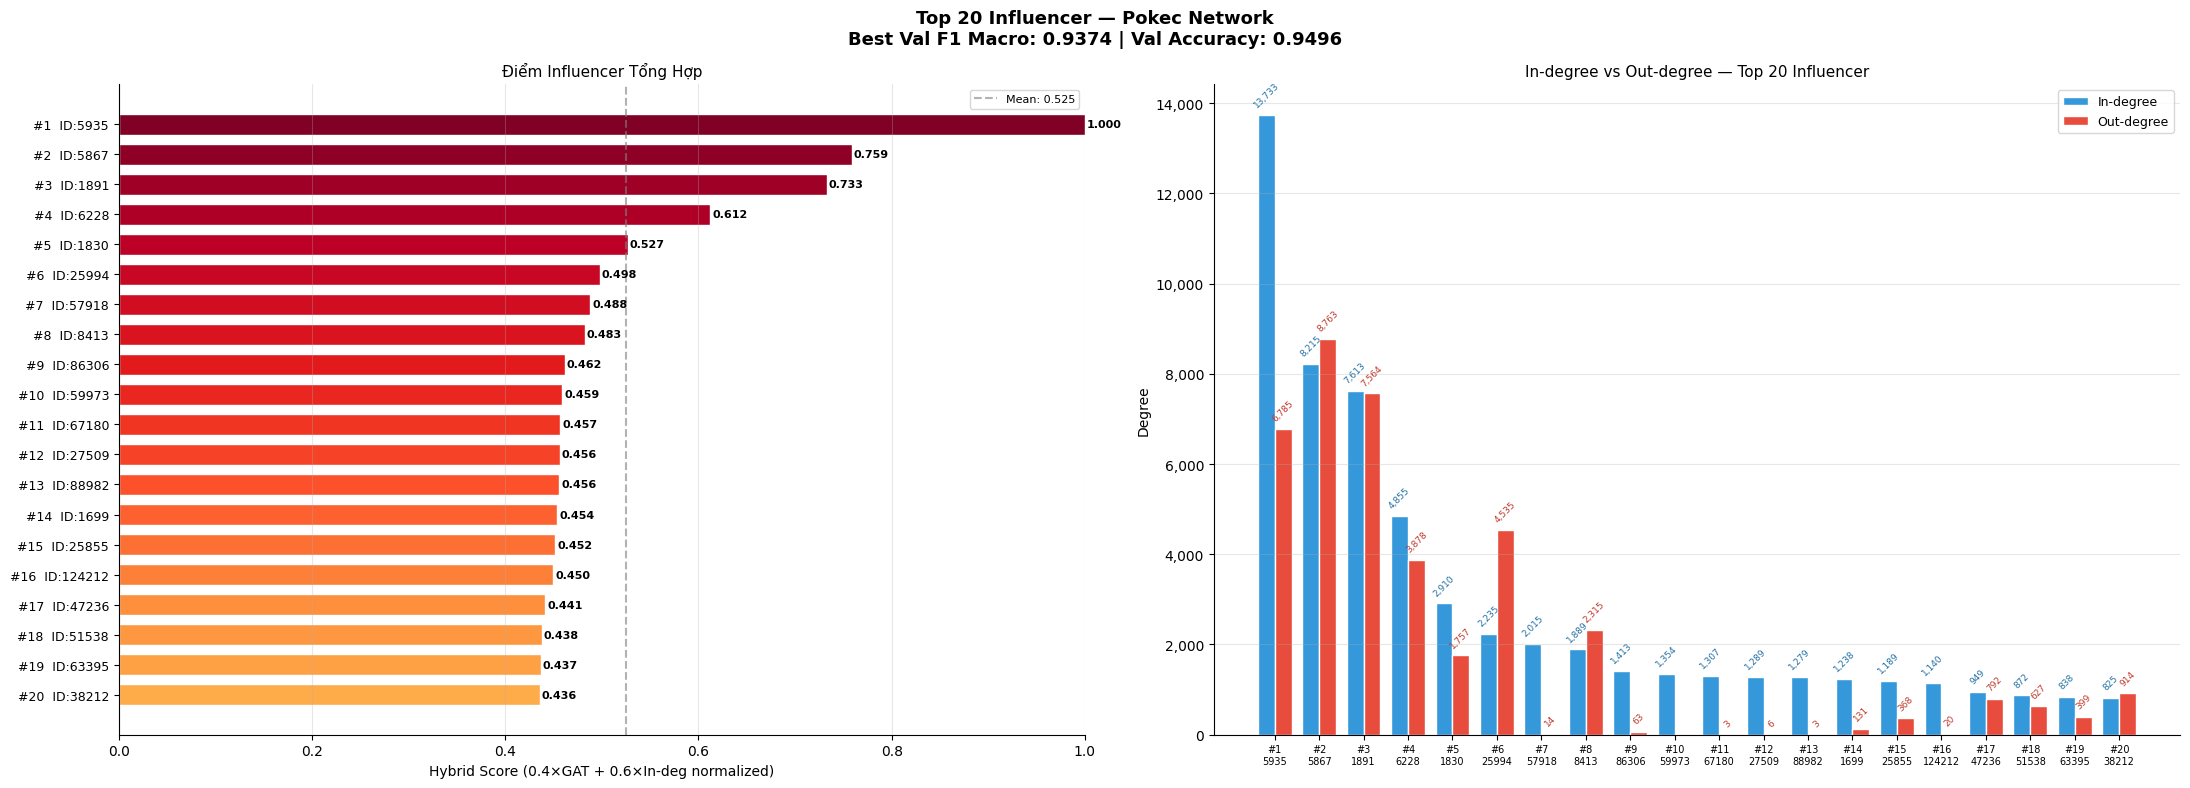

In [134]:
top20_scores = hybrid_score[top20_idx]
top20_indeg  = in_deg[top20_idx]
top20_outdeg = out_deg[top20_idx]
orig_ids_list = list(all_nodes)
node_ids     = [orig_ids_list[i] for i in top20_idx]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle(
    f'Top 20 Influencer — Pokec Network\n'
    f'Best Val F1 Macro: {best_val_f1:.4f} | Val Accuracy: {v_acc:.4f}',
    fontsize=13, fontweight='bold'
)

colors_top = plt.cm.YlOrRd(np.linspace(0.4, 1.0, 20))[::-1]
tick_labels = [f'#{i+1}  ID:{node_ids[i]}' for i in range(20)]

# --- Panel 1: Hybrid Score ---
ax1 = axes[0]
bars = ax1.barh(range(20, 0, -1), top20_scores, color=colors_top, edgecolor='white', height=0.7)
ax1.set_yticks(range(20, 0, -1))
ax1.set_yticklabels(tick_labels, fontsize=9)
for bar, score in zip(bars, top20_scores):
    ax1.text(score + 0.002, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=8, fontweight='bold')
ax1.set_xlabel('Hybrid Score (0.4×GAT + 0.6×In-deg normalized)', fontsize=10)
ax1.set_title('Điểm Influencer Tổng Hợp', fontsize=11)
ax1.set_xlim(0, min(1.0, top20_scores.max() * 1.12))
ax1.axvline(x=top20_scores.mean(), color='gray', linestyle='--', alpha=0.6,
            label=f'Mean: {top20_scores.mean():.3f}')
ax1.legend(fontsize=8)
ax1.grid(axis='x', alpha=0.3)
ax1.spines[['top','right']].set_visible(False)

# --- Panel 2: In-deg vs Out-deg ---
ax2 = axes[1]
x = np.arange(20)
w = 0.38
b1 = ax2.bar(x - w/2, top20_indeg,  width=w, label='In-degree',  color='#3498db', edgecolor='white')
b2 = ax2.bar(x + w/2, top20_outdeg, width=w, label='Out-degree', color='#e74c3c', edgecolor='white')

for bar, v in zip(b1, top20_indeg):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + top20_indeg.max()*0.01,
             f'{int(v):,}', ha='center', va='bottom', fontsize=6.5, rotation=45, color='#2471a3')
for bar, v in zip(b2, top20_outdeg):
    if v > 0:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + top20_indeg.max()*0.01,
                 f'{int(v):,}', ha='center', va='bottom', fontsize=6.5, rotation=45, color='#c0392b')

ax2.set_xticks(x)
ax2.set_xticklabels([f'#{i+1}\n{node_ids[i]}' for i in range(20)], fontsize=7)
ax2.set_ylabel('Degree', fontsize=10)
ax2.set_title('In-degree vs Out-degree — Top 20 Influencer', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
ax2.spines[['top','right']].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

Kết quả trên Test Set:
              precision    recall  f1-score   support

  Clone/Spam       0.95      0.97      0.96    114246
      Casual       0.99      0.95      0.97    743279
   Potential       0.85      0.96      0.90    228387
  Influencer       0.90      0.95      0.92     57057

    accuracy                           0.95   1142969
   macro avg       0.92      0.95      0.94   1142969
weighted avg       0.95      0.95      0.95   1142969



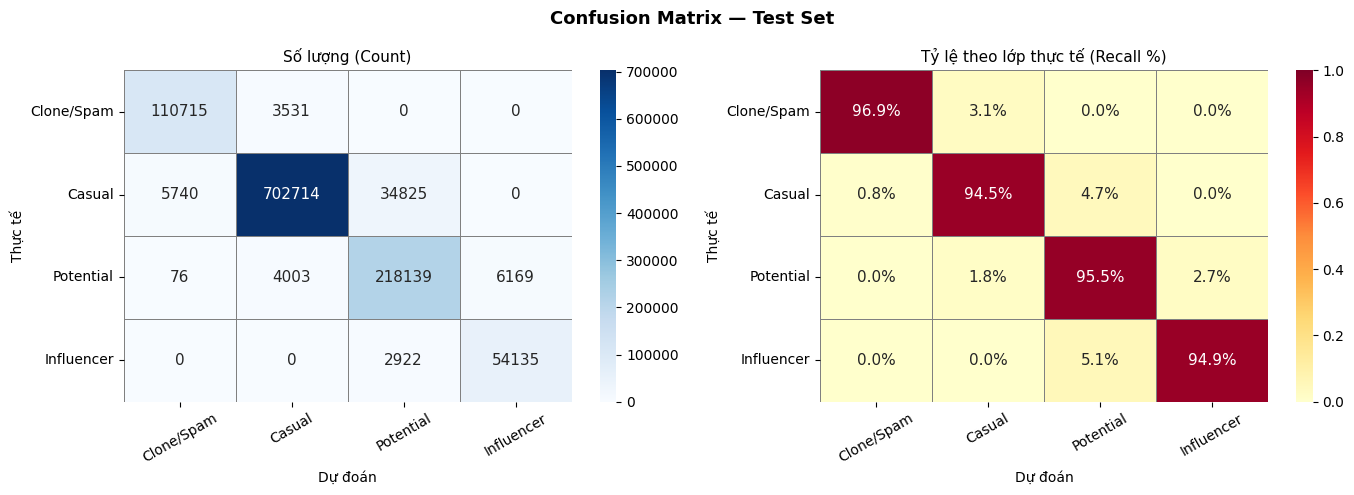

In [135]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    test_preds  = logits[data.test_mask].argmax(dim=1).cpu().numpy()
    test_truths = data.y[data.test_mask].cpu().numpy()

print('Kết quả trên Test Set:')
print(classification_report(
    test_truths, test_preds,
    target_names=['Clone/Spam', 'Casual', 'Potential', 'Influencer'],
    zero_division=0
))

# ====================== CONFUSION MATRIX ======================
cm = confusion_matrix(test_truths, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # chuẩn hóa theo hàng

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Test Set ', fontsize=13, fontweight='bold')

labels = ['Clone/Spam', 'Casual', 'Potential', 'Influencer']

# --- Trái: số lượng thực tế ---
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11}, ax=axes[0])
axes[0].set_title('Số lượng (Count)', fontsize=11)
axes[0].set_xlabel('Dự đoán', fontsize=10)
axes[0].set_ylabel('Thực tế', fontsize=10)
axes[0].tick_params(axis='x', rotation=30)
axes[0].tick_params(axis='y', rotation=0)

# --- Phải: tỷ lệ % theo hàng (recall từng class) ---
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='YlOrRd',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='gray',
            annot_kws={'size': 11}, vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Tỷ lệ theo lớp thực tế (Recall %)', fontsize=11)
axes[1].set_xlabel('Dự đoán', fontsize=10)
axes[1].set_ylabel('Thực tế', fontsize=10)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()